# Run this first !
Ensures correct libraries and imports data

In [1]:

# Run this first !
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")
print(loading.exports(DATA))
print(loading.files(DATA))

utt = loading.load(DATA, "all_utterances.csv", "2026-09-13")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-13")
met = loading.load(DATA, "all_metrics.csv", "2026-09-13")

print(utt.shape, sent.shape, met.shape)
sent.head()
data=sent.copy()

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data
['2026-09-13']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  1201 rows
loaded all_sentences.csv  9519 rows
loaded all_metrics.csv  510 rows
(1201, 11) (9519, 12) (510, 6)


In [2]:
print(loading.exports(DATA))
print(loading.files(DATA))

utt = loading.load(DATA, "all_utterances.csv", "2026-09-13")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-13")
met = loading.load(DATA, "all_metrics.csv", "2026-09-13")

print(utt.shape, sent.shape, met.shape)
sent.head()

['2026-09-13']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  1201 rows
loaded all_sentences.csv  9519 rows
loaded all_metrics.csv  510 rows
(1201, 11) (9519, 12) (510, 6)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence
0,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9789,1,"Good morning, ladies and gentlemen."
1,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9790,2,Welcome to JPMorgan Chase’s First Quarter 2023...
2,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9791,3,This call is being recorded.
3,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9792,4,Your line will be muted for the duration of th...
4,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9793,5,We will now go live to the presentation.


In [3]:
data=sent.copy()

# Sentence pre-processing (stop words, speaker names and greetings etc)
This is just a starting point as there are several oddities - for example greeting words mean the Bert Emotion skews towards "Joy" and some stopwords such as "us" seems to be treated as a plural of "u" - hence needs removing. Also need to work out how to differentiate between "credit" and "Credit Suisse" as both are valid but cannot be treated as the same

### Import nltk

In [4]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Speaker Names
Need to remove these from the sentences

In [5]:
# Create a list using "speaker_name" column from the dataframe
speaker_names = data["speaker_name"].tolist()
# Reduce list to contain only unique speaker names
speaker_names = list(set(speaker_names))
# Split first and last names of the speakers
speaker_names_split = [name.split() for name in speaker_names]
# remove capital letters from speaker names
speaker_names_split = [[name.lower() for name in sublist] for sublist in speaker_names_split]
speaker_names_split[:10]

[['adam', 'terelak'],
 ['operator'],
 ['vishal', 'shah'],
 ['stefan', 'stalmann'],
 ['jim', 'mitchell'],
 ['saul', 'martinez'],
 ['anke', 'reingen'],
 ['tom', 'hallett'],
 ['piers', 'brown'],
 ['glenn', 'schorr']]

### Pre-processing Function

In [6]:
def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., NaN
        return []
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))

    # Remove words that are not informative for topic modeling
    stop_words.update(['also', 'quarter', 'year', 'u', 'think', 'thats'])

    # Remove speaker names from the text
    speaker_names_flat = [name for sublist in speaker_names_split for name in sublist]
    

    greeting_words = {
    "hello", "hi", "dear", "greetings",
    "thank", "thanks", "good", "morning",
    "afternoon", "evening",
    "ladies", "gentlemen", "sir", "madam",
    "yeah", "welcome",
    "mr", "mrs", "ms"
}

    lemmatizer = WordNetLemmatizer()
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word not in stop_words and word.isalpha() and word not in greeting_words and word not in speaker_names_flat # Ensure only alphabetic words are kept and remove greeting words and speaker names
    ]
    return [word for word in cleaned_tokens if word not in stop_words]

In [7]:
# Apply the preprocessing function
data['cleaned_text'] = data['sentence'].apply(preprocess_text)

# Display the first few rows
print(data[['sentence', 'cleaned_text']].head(10))

                                            sentence  \
0                Good morning, ladies and gentlemen.   
1  Welcome to JPMorgan Chase’s First Quarter 2023...   
2                       This call is being recorded.   
3  Your line will be muted for the duration of th...   
4           We will now go live to the presentation.   
5                                   Please stand by.   
6  At this time, I would like to turn the call ov...   
7                       Mr. Barnum, please go ahead.   
8                Thanks, and good morning, everyone.   
9  The presentation is available on our website, ...   

                                        cleaned_text  
0                                                 []  
1           [jpmorgan, chase, first, earnings, call]  
2                                   [call, recorded]  
3                      [line, muted, duration, call]  
4                           [go, live, presentation]  
5                                    [please, stand] 

# JPM Data

In [8]:
# Create dataframe with bank = jpm
jpm_data = data[data['bank'] == 'JPM'].copy()
print(jpm_data.shape)
jpm_data.head(2)

(4805, 13)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text
0,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9789,1,"Good morning, ladies and gentlemen.",[]
1,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9790,2,Welcome to JPMorgan Chase’s First Quarter 2023...,"[jpmorgan, chase, first, earnings, call]"


## FinBert: All sections

Truncation = True means only 512 tokens (350 -400 words) are kept. Anything longer is ignored. Also output contains top_k = None so that the scores for all the emotions are retained to allow comparison later on

In [9]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# Load FinBERT model and tokenizer
model_name = "yiyanghkust/finbert-tone"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    jpm_data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

/Users/rdrobinson/Cambridge/boe-financial-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 59066.43it/s]


In [10]:
# Run the model and keep all sentiment scores
basic_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
jpm_data["main_sentiment"] = [
    max(row, key=row.get, default="neutral") if row else "neutral"
    for row in sentiment_rows
]
jpm_data["main_sentiment_score"] = [
    row.get(max(row, key=row.get, default="neutral"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns - NOTE: Needs capital letters to work !
for sentiment in ["Positive", "Negative", "Neutral"]:
    jpm_data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]

In [11]:
jpm_data.head(2)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text,main_sentiment,main_sentiment_score,Positive,Negative,Neutral
0,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9789,1,"Good morning, ladies and gentlemen.",[],Neutral,0.967353,0.030688,0.001959,0.967353
1,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9790,2,Welcome to JPMorgan Chase’s First Quarter 2023...,"[jpmorgan, chase, first, earnings, call]",Neutral,0.999693,0.000068,0.000239,0.999693


In [12]:
jpm_data.tail(2)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text,main_sentiment,main_sentiment_score,Positive,Negative,Neutral
4803,JPM,2024-Q4,earnings,2025-01-15,80,qa,operator,Operator,NaN,14273,1,Thank you all for participating in today's con...,"[participating, today, conference]",Neutral,0.999947,0.000021,0.000032,0.999947
4804,JPM,2024-Q4,earnings,2025-01-15,80,qa,operator,Operator,NaN,14274,2,"You may disconnect at this time, and have a gr...","[may, disconnect, time, great, rest, day]",Neutral,0.714476,0.281143,0.004381,0.714476


## Split by Section to check speakers
Are the same speakers who give the presentation, the same as those who are involved in the Q&A. If so then their language can be directly compared in both

In [13]:
# Create jpm dataframe with section = 'prepared'
jpm_prepared_data = jpm_data[jpm_data['section'] == 'prepared'].copy()
print(jpm_prepared_data.shape)
jpm_prepared_data.head(2)


(942, 18)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text,main_sentiment,main_sentiment_score,Positive,Negative,Neutral
0,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9789,1,"Good morning, ladies and gentlemen.",[],Neutral,0.967353,0.030688,0.001959,0.967353
1,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9790,2,Welcome to JPMorgan Chase’s First Quarter 2023...,"[jpmorgan, chase, first, earnings, call]",Neutral,0.999693,0.000068,0.000239,0.999693


In [14]:
# Count different numbers of speakers in JPM prepared section
jpm_prepared_speaker_counts = jpm_prepared_data['speaker_name'].value_counts()
print(jpm_prepared_speaker_counts)

speaker_name
Jeremy Barnum    855
Operator          77
Jamie Dimon       10
Name: count, dtype: int64


In [15]:
jpm_prepared_data['speaker_role'].value_counts()

speaker_role
management    865
operator       77
Name: count, dtype: int64

There are 3 key speakers in the presentation section, all of which are listed as Management

In [16]:
# Create jpm dataframe with section = 'q&a'
jpm_qa_data = jpm_data[jpm_data['section'] == 'qa'].copy()
print(jpm_qa_data.shape)
jpm_qa_data.head(2)

(3863, 18)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text,main_sentiment,main_sentiment_score,Positive,Negative,Neutral
112,JPM,2023-Q1,earnings,2023-04-14,3,qa,operator,Operator,NaN,9901,1,Please stand by.,"[please, stand]",Neutral,0.996865,0.000663,0.002471,0.996865
113,JPM,2023-Q1,earnings,2023-04-14,3,qa,operator,Operator,NaN,9902,2,The first question is coming from the line of ...,"[first, question, coming, line, steve, wolfe, ...",Neutral,0.998579,0.000029,0.001392,0.998579


In [17]:
# Count different numbers of speakers in JPM q&a section
jpm_qa_speaker_counts = jpm_qa_data['speaker_name'].value_counts()
print(jpm_qa_speaker_counts)

speaker_name
Jeremy Barnum           1673
Jamie Dimon              688
Operator                 268
Mike Mayo                150
Betsy L. Graseck         146
Gerard Cassidy           125
Erika Najarian           107
Ebrahim H. Poonawala     100
Glenn Schorr              97
Matt O'Connor             97
Jim Mitchell              95
Steven Chubak             79
John McDonald             69
Ken Usdin                 52
Charles W. Peabody        43
Saul Martinez             36
Ryan Kenny                14
Scott Siefers             13
Manan Gosalia             11
Name: count, dtype: int64


In [18]:
jpm_qa_data['speaker_role'].value_counts()

speaker_role
management    2361
analyst       1234
operator       268
Name: count, dtype: int64

In [19]:
# check names of speakers in Q&A section who are management - and therefore answering the questions
jpm_qa_data[jpm_qa_data['speaker_role'] == 'management']['speaker_name'].unique()

array(['Jeremy Barnum', 'Jamie Dimon'], dtype=object)

Both speakers listed as Management in the Q&A session match those in the presentation section and therefore their responses during a scripted presentation vs an open Q&A session can be investigated. Not sure who 'operator' is !

## Calculate quarterly statistics 
Outlier check, plus median and standard deviation of each emotion per quarter

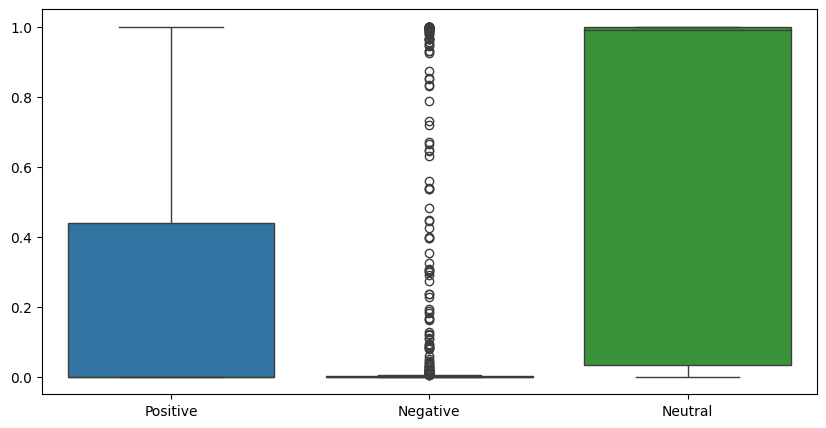

In [20]:
# Look for outliers in sentiments of jpm_prepared_data
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize outliers of last 3 columns (sentiments) using boxplots
# Display as vertical boxes on the same plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=jpm_prepared_data.iloc[:, -3:])
plt.show()


There are some significant outliers in the data for all the emotions. Hence use the median rather than the mean

### Presentation Section

In [21]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (JPM)
jpm_prepared_sentiment_stats = jpm_prepared_data.groupby(["quarter", "main_sentiment"]).agg(
    median_score=("main_sentiment_score", "median"),
    std_score=("main_sentiment_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()
jpm_prepared_sentiment_stats.head(10)

,quarter,main_sentiment,median_score,std_score
0,2023-Q1,Negative,0.993446,0.119396
1,2023-Q1,Neutral,0.999525,0.078299
2,2023-Q1,Positive,0.999920,0.085182
3,2023-Q2,Negative,0.999174,0.168843
4,2023-Q2,Neutral,0.999595,0.074407
5,2023-Q2,Positive,0.999991,0.147384
6,2023-Q3,Negative,0.949535,0.186709
7,2023-Q3,Neutral,0.999052,0.089300
8,2023-Q3,Positive,0.999896,0.127575
9,2023-Q4,Negative,0.999469,0.040713


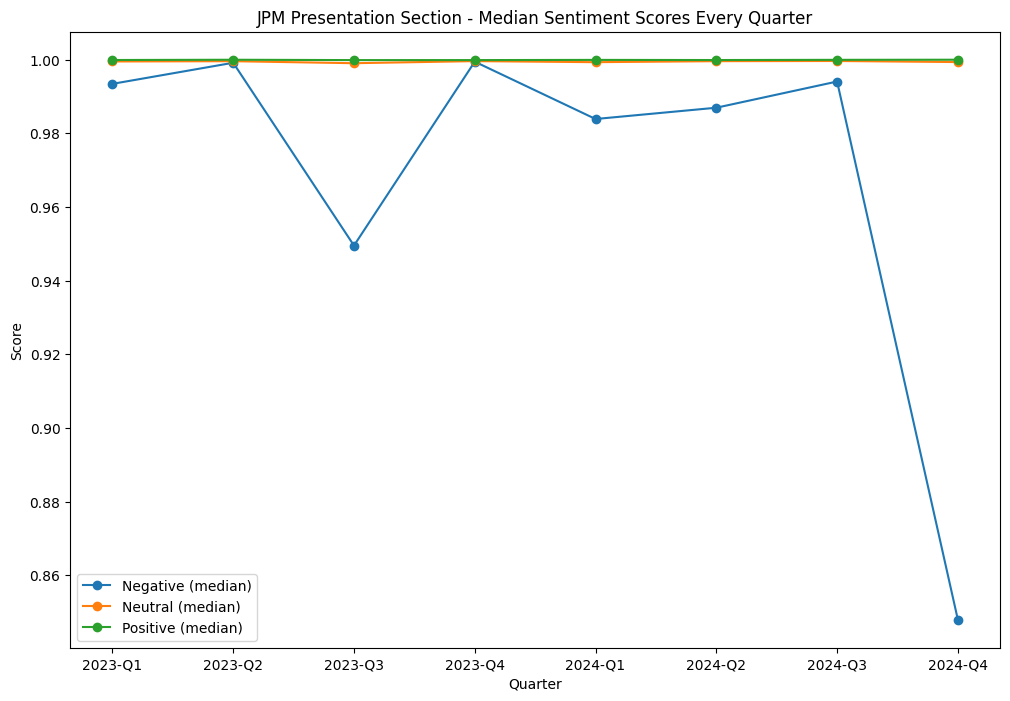

In [22]:
# Plot median for sentiment every quarter as a scatter plot on the same plot (JPM)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for sentiment in jpm_prepared_sentiment_stats["main_sentiment"].unique():
    jpm_sentiment_prepared_data = jpm_prepared_sentiment_stats[jpm_prepared_sentiment_stats["main_sentiment"] == sentiment]
    plt.plot(jpm_sentiment_prepared_data["quarter"], jpm_sentiment_prepared_data["median_score"], label=f"{sentiment} (median)", marker='o')
plt.title("JPM Presentation Section - Median Sentiment Scores Every Quarter")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.legend()
plt.show()

### Q&A Section
Only those listed as Management who are answering the questions (not the questions themselves)

In [23]:
# Drop rows with speaker role = analyst
jpm_m_qa_data = jpm_qa_data[jpm_qa_data["speaker_role"] != "analyst"].reset_index(drop=True)

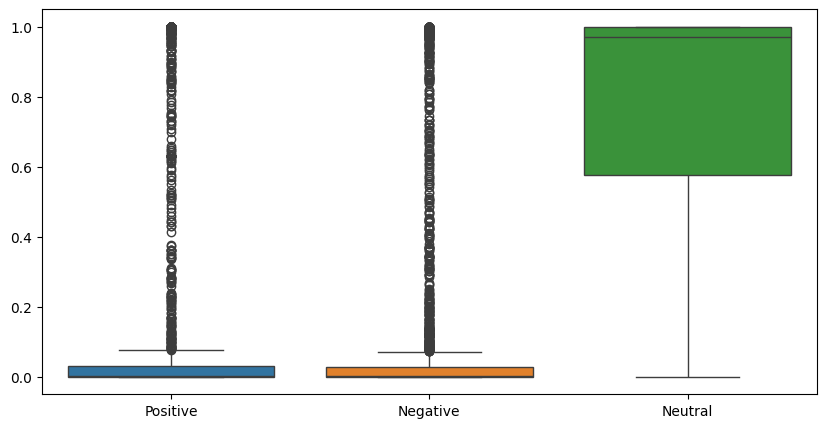

In [24]:
# Look for outliers in sentiment of jpm_qa_data
# Visualize outliers of last 3 columns (sentiments) using boxplots
# Display as vertical boxes on the same plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=jpm_m_qa_data.iloc[:, -3:])
plt.show()

Again there are plenty of outliers - hence use the median rather than the mean

In [25]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (JPM)
jpm_m_qa_sentiment_stats = jpm_m_qa_data.groupby(["quarter", "main_sentiment"]).agg(
    median_score=("main_sentiment_score", "median"),
    std_score=("main_sentiment_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()
jpm_m_qa_sentiment_stats.head(10)

,quarter,main_sentiment,median_score,std_score
0,2023-Q1,Negative,0.970366,0.128149
1,2023-Q1,Neutral,0.994368,0.103686
2,2023-Q1,Positive,0.983154,0.180639
3,2023-Q2,Negative,0.981655,0.132595
4,2023-Q2,Neutral,0.994529,0.087722
5,2023-Q2,Positive,0.999987,0.140673
6,2023-Q3,Negative,0.949848,0.145005
7,2023-Q3,Neutral,0.991169,0.106337
8,2023-Q3,Positive,0.998233,0.132103
9,2023-Q4,Negative,0.991714,0.139025


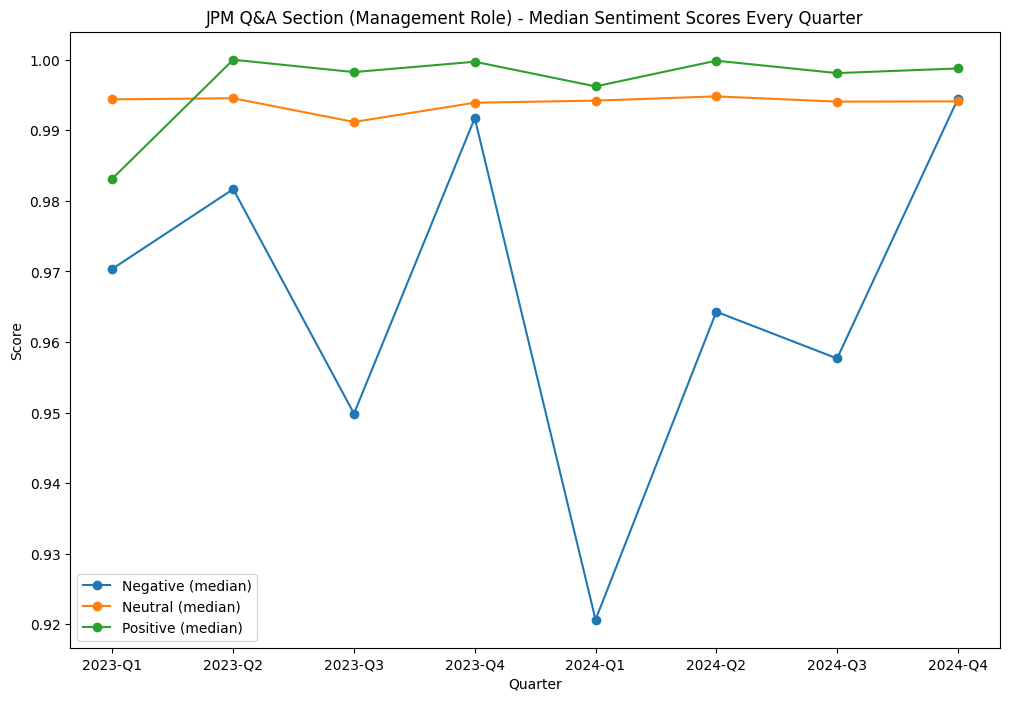

In [26]:
# Plot median for sentiment every quarter as a scatter plot on the same plot (JPM) - Management role during Q&A
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for sentiment in jpm_m_qa_sentiment_stats["main_sentiment"].unique():
    jpm_sentiment_m_qa_data = jpm_m_qa_sentiment_stats[jpm_m_qa_sentiment_stats["main_sentiment"] == sentiment]
    plt.plot(jpm_sentiment_m_qa_data["quarter"], jpm_sentiment_m_qa_data["median_score"], label=f"{sentiment} (median)", marker='o')
plt.title("JPM Q&A Section (Management Role) - Median Sentiment Scores Every Quarter")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.legend()
plt.show()

### Analysts
These show much more erratic changes in sentiment - presumablky due to the number of different question types

In [27]:
# Drop rows with speaker role = management
jpm_a_qa_data = jpm_qa_data[jpm_qa_data["speaker_role"] != "management"].reset_index(drop=True)

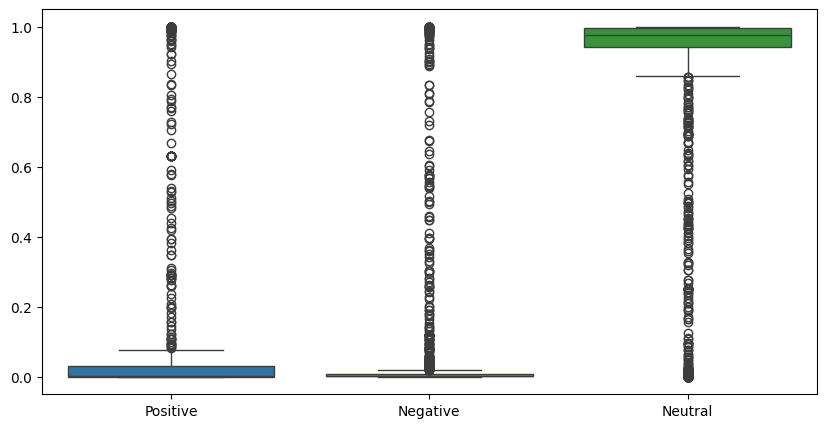

In [28]:
# Look for outliers in sentiments of ubs_qa_data
# Visualize outliers of last 3 columns (sentiments) using boxplots
# Display as vertical boxes on the same plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=jpm_a_qa_data.iloc[:, -3:])
plt.show()

All have lots of outliers - hence use median

In [29]:
# Create dataframe to calculate mean and standard deviation of every sentiment every quarter (JPM)
jpm_a_qa_sentiment_stats = jpm_a_qa_data.groupby(["quarter", "main_sentiment"]).agg(
    median_score=("main_sentiment_score", "median"),
    std_score=("main_sentiment_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()
jpm_a_qa_sentiment_stats.head(10)

,quarter,main_sentiment,median_score,std_score
0,2023-Q1,Negative,0.980487,0.202574
1,2023-Q1,Neutral,0.982099,0.073809
2,2023-Q1,Positive,0.996983,0.140336
3,2023-Q2,Negative,0.959891,0.176040
4,2023-Q2,Neutral,0.990932,0.069217
5,2023-Q2,Positive,0.996983,0.179676
6,2023-Q3,Negative,0.994929,0.202967
7,2023-Q3,Neutral,0.984934,0.055850
8,2023-Q3,Positive,0.992456,0.182677
9,2023-Q4,Negative,0.977109,0.171549


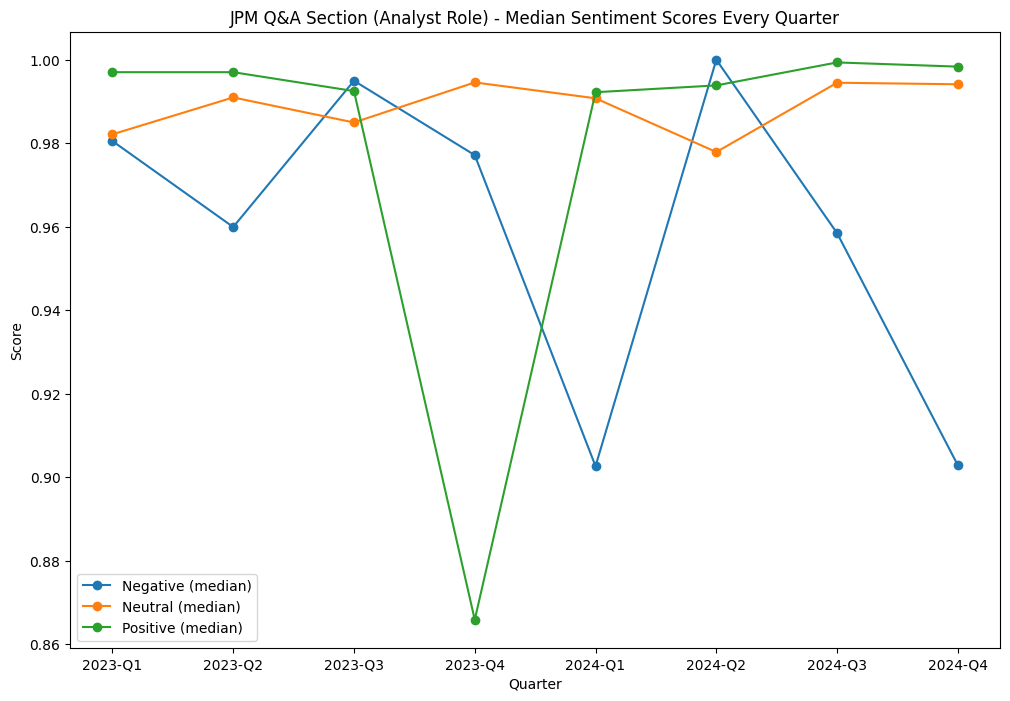

In [30]:
# Plot median for sentiment every quarter as a scatter plot on the same plot (JPM) - Analyst role during Q&A
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for sentiment in jpm_a_qa_sentiment_stats["main_sentiment"].unique():
    jpm_sentiment_a_qa_data = jpm_a_qa_sentiment_stats[jpm_a_qa_sentiment_stats["main_sentiment"] == sentiment]
    plt.plot(jpm_sentiment_a_qa_data["quarter"], jpm_sentiment_a_qa_data["median_score"], label=f"{sentiment} (median)", marker='o')
plt.title("JPM Q&A Section (Analyst Role) - Median Sentiment Scores Every Quarter")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.legend()
plt.show()

## Find differences between Presentation and Q&A (Management roles)

In [31]:
# Create one dataframe from ubs_prepared_sentiment_stats and ubs_qa_filtered_sentiment_stats for comparison plots and retain column for prepared vs Q&A
jpm_comparison_sentiment_stats = pd.concat([
    jpm_prepared_sentiment_stats.assign(source="prepared"),
    jpm_a_qa_sentiment_stats.assign(source="Q&A")
]).reset_index(drop=True)
jpm_comparison_sentiment_stats.head(10)

,quarter,main_sentiment,median_score,std_score,source
0,2023-Q1,Negative,0.993446,0.119396,prepared
1,2023-Q1,Neutral,0.999525,0.078299,prepared
2,2023-Q1,Positive,0.999920,0.085182,prepared
3,2023-Q2,Negative,0.999174,0.168843,prepared
4,2023-Q2,Neutral,0.999595,0.074407,prepared
5,2023-Q2,Positive,0.999991,0.147384,prepared
6,2023-Q3,Negative,0.949535,0.186709,prepared
7,2023-Q3,Neutral,0.999052,0.089300,prepared
8,2023-Q3,Positive,0.999896,0.127575,prepared
9,2023-Q4,Negative,0.999469,0.040713,prepared


In [32]:
jpm_comparison_sentiment_stats.tail(10)

,quarter,main_sentiment,median_score,std_score,source
38,2024-Q1,Positive,0.992182,0.165981,Q&A
39,2024-Q2,Negative,0.999969,0.067729,Q&A
40,2024-Q2,Neutral,0.977854,0.104791,Q&A
41,2024-Q2,Positive,0.993815,0.163849,Q&A
42,2024-Q3,Negative,0.958416,0.178236,Q&A
43,2024-Q3,Neutral,0.994459,0.064724,Q&A
44,2024-Q3,Positive,0.999321,0.143620,Q&A
45,2024-Q4,Negative,0.902799,0.185834,Q&A
46,2024-Q4,Neutral,0.994085,0.071958,Q&A
47,2024-Q4,Positive,0.998314,0.187708,Q&A


### Plot option 1: Subtracting Presentation from Q&A
Any increase is due to the Q&A section having greater emotion score than the presentation section (e.g. Q2 2023 increase in fear from the takeover and Q3 & Q4 2023 increase in sadness from the Q&A)

In [33]:
# Find the difference between Q&A and prepared mean scores for each sentiment and quarter
jpm_diff_sentiment_stats = jpm_comparison_sentiment_stats.pivot_table(
    index=["quarter", "main_sentiment"],
    columns="source",
    values="median_score",
    # if NaN values, replace with 0
    fill_value=0,
).reset_index()
jpm_diff_sentiment_stats["diff"] = jpm_diff_sentiment_stats["Q&A"] - jpm_diff_sentiment_stats["prepared"]
jpm_diff_sentiment_stats.head(10)


source,quarter,main_sentiment,Q&A,prepared,diff
0,2023-Q1,Negative,0.980487,0.993446,-0.012959
1,2023-Q1,Neutral,0.982099,0.999525,-0.017426
2,2023-Q1,Positive,0.996983,0.999920,-0.002937
3,2023-Q2,Negative,0.959891,0.999174,-0.039283
4,2023-Q2,Neutral,0.990932,0.999595,-0.008664
5,2023-Q2,Positive,0.996983,0.999991,-0.003008
6,2023-Q3,Negative,0.994929,0.949535,0.045394
7,2023-Q3,Neutral,0.984934,0.999052,-0.014119
8,2023-Q3,Positive,0.992456,0.999896,-0.007440
9,2023-Q4,Negative,0.977109,0.999469,-0.022360


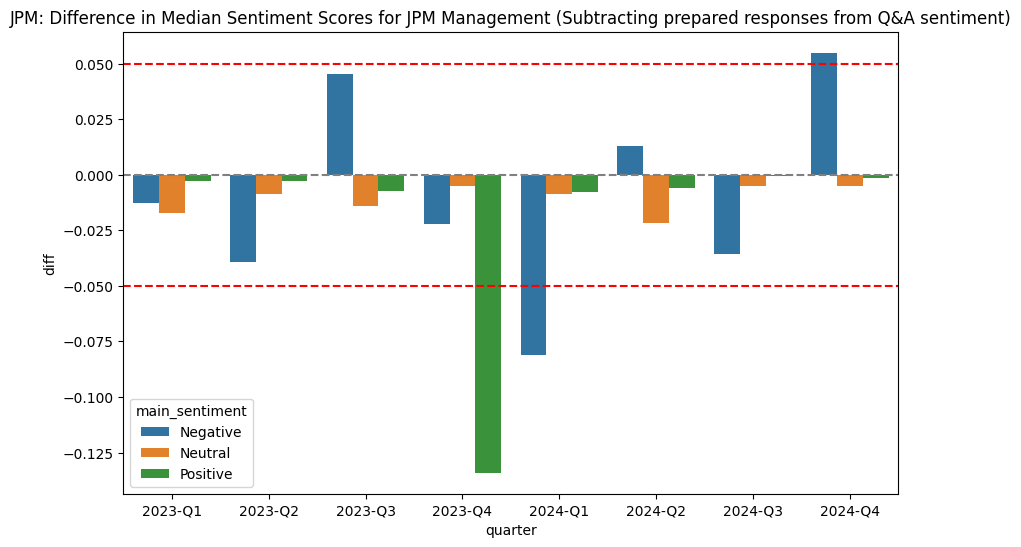

In [34]:
# Display the combined sentiment stats for JPM Q&A and prepared data as a bar plot
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=jpm_diff_sentiment_stats, x="quarter", y="diff", hue="main_sentiment")
plt.axhline(0, linestyle='--', color='gray')
# Add axis line for 20% change in emotion scores
plt.axhline(0.05, linestyle='--', color='red')
plt.axhline(-0.05, linestyle='--', color='red')
plt.title("JPM: Difference in Median Sentiment Scores for JPM Management (Subtracting prepared responses from Q&A sentiment)")
plt.show()

###  Plot option 2: Subtracting Q&A from Presentation sections
Any increase is due to the presentation section having greater emotion score than the Q&A section (e.g. Q2 2023 was the merge announcement - hence increase in surprise)

In [35]:
# Find the difference between Q&A and prepared mean scores for each sentiment and quarter
jpm_diff2_sentiment_stats = jpm_comparison_sentiment_stats.pivot_table(
    index=["quarter", "main_sentiment"],
    columns="source",
    values="median_score",
    # if NaN values, replace with 0
    fill_value=0,
).reset_index()
jpm_diff2_sentiment_stats["diff"] = jpm_diff2_sentiment_stats["prepared"] - jpm_diff2_sentiment_stats["Q&A"]
jpm_diff2_sentiment_stats.head(10)

source,quarter,main_sentiment,Q&A,prepared,diff
0,2023-Q1,Negative,0.980487,0.993446,0.012959
1,2023-Q1,Neutral,0.982099,0.999525,0.017426
2,2023-Q1,Positive,0.996983,0.999920,0.002937
3,2023-Q2,Negative,0.959891,0.999174,0.039283
4,2023-Q2,Neutral,0.990932,0.999595,0.008664
5,2023-Q2,Positive,0.996983,0.999991,0.003008
6,2023-Q3,Negative,0.994929,0.949535,-0.045394
7,2023-Q3,Neutral,0.984934,0.999052,0.014119
8,2023-Q3,Positive,0.992456,0.999896,0.007440
9,2023-Q4,Negative,0.977109,0.999469,0.022360


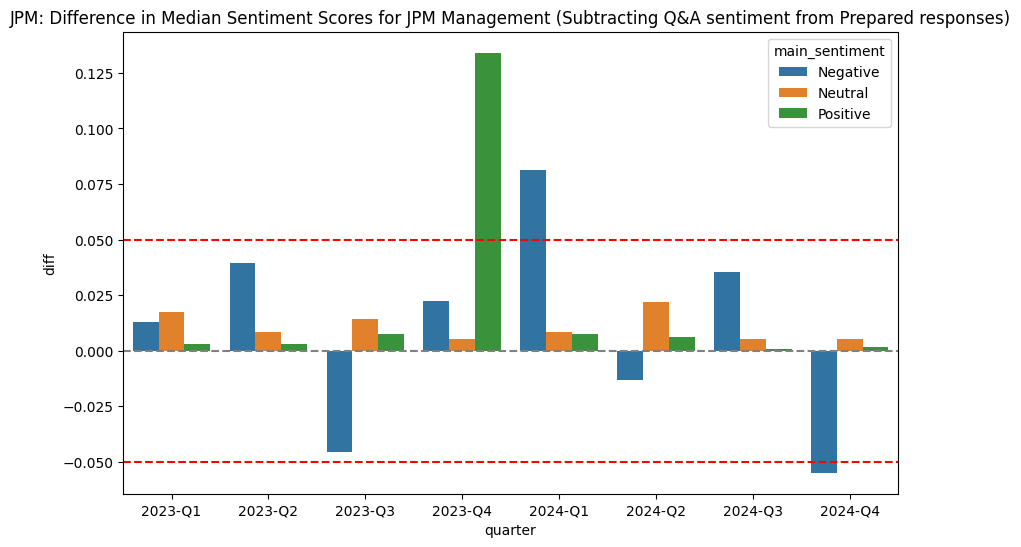

In [36]:
# Display the combined sentiment stats for UBS Q&A and prepared data as a bar plot
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=jpm_diff2_sentiment_stats, x="quarter", y="diff", hue="main_sentiment")
plt.axhline(0, linestyle='--', color='gray')
# Add axis line for 20% change in emotion scores
plt.axhline(0.05, linestyle='--', color='red')
plt.axhline(-0.05, linestyle='--', color='red')
plt.title("JPM: Difference in Median Sentiment Scores for JPM Management (Subtracting Q&A sentiment from Prepared responses)")
plt.show()

## Final timeline (JPM)

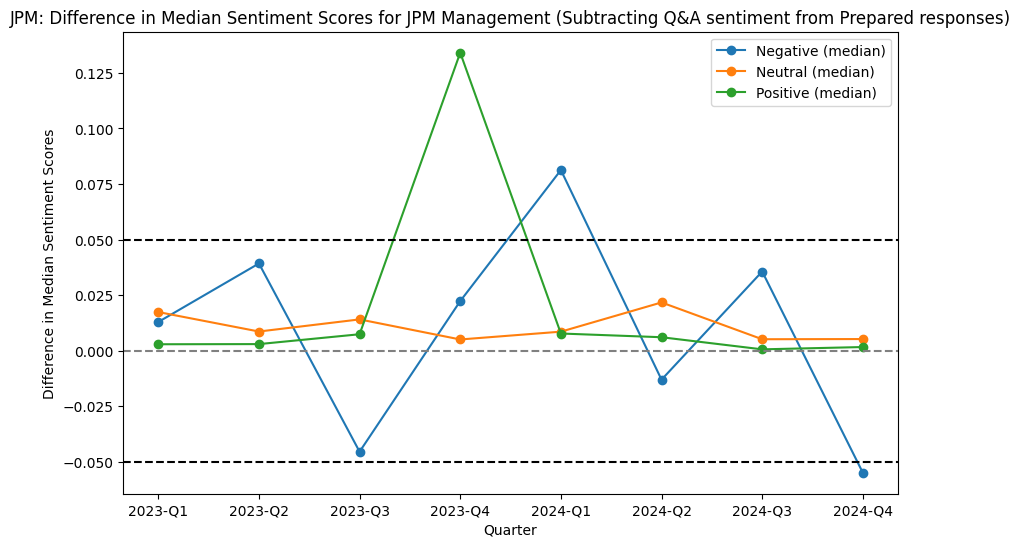

In [37]:
# Plot as line graph
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for sentiment in jpm_diff2_sentiment_stats["main_sentiment"].unique():
    sentiment_data = jpm_diff2_sentiment_stats[jpm_diff2_sentiment_stats["main_sentiment"] == sentiment]
    plt.plot(sentiment_data["quarter"], sentiment_data["diff"], label=f"{sentiment} (median)", marker='o')
plt.axhline(0, linestyle='--', color='gray')
plt.axhline(0.05, linestyle='--', color='black')
plt.axhline(-0.05, linestyle='--', color='black')
plt.title("JPM: Difference in Median Sentiment Scores for JPM Management (Subtracting Q&A sentiment from Prepared responses)")
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Sentiment Scores")
plt.legend()
plt.show()


In [38]:
# Save figure
plt.savefig("FinBert_JPM_timeline.png")

<Figure size 640x480 with 0 Axes>

## Final summary
Significant changes when using MEDIAN: 

**From FinBert**. 

**Q4 2023**
* More positive sentiment in presentation than Q&A. 

* BertEmotion  showed more "fear" in the presentation and more "love" and "surprise" in the Q&A

**Q1 2024 & Q4 2024**
* More negative sentiment in presentation than Q&A. 

* Q1 2024 BertEmotion only showed more "surprise" in the Q&A
* Q4 2024 BertEmotion showed more "sadness" & "surprise" in the Q&A


----------


**Reminder: From BertEmotion**. 

**Q1 - Q4 2023**
* Love - more in Q&A section than in the presentation (more postive sentiment in Q&A)

**Q2 2023 to end**
* Surprise - consistently more in the Q&A section than the presentation (could be tone of questions)

**Q1 2023 and Q2 2024**
* Sadness - slight effect of more in Q&A than presentation (slightly more negative Q&A than presentation)

**Q4 2023**
* Fear - slight effect of more in presentation than in Q&A (unusual as presentation will be scripted)
